In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Veriyi temiz bir şekilde tekrar okuyalım
print("Veri yükleniyor...")
df_real = pd.read_csv("../data/raw/malicious_phish.csv")

# Hedef değişkeni oluştur (benign -> 0, diğerleri -> 1)
df_real['label'] = df_real['type'].apply(lambda x: 0 if x == 'benign' else 1)
print("Veri başarıyla yüklendi!")

# 2. NLP: TF-IDF Vektörizasyonu
# token_pattern=r'[A-Za-z0-9\-]+' parametresi, URL'yi noktalardan ve slash'lardan kurtarıp saf kelimelere böler
# max_features=3000: Modelin kafası karışmasın diye internetteki en sık kullanılan 3000 kelimeyi/parçayı seçiyoruz
print("NLP (TF-IDF) kelime analizi başlıyor... (Bu işlem 1-2 dakika sürebilir, lütfen bekle)")

tfidf = TfidfVectorizer(token_pattern=r'[A-Za-z0-9\-]+', max_features=3000)

# Ham URL metinlerini alıp, 3000 sütunlu bir matematiksel matrise (sayılara) çeviriyoruz
X_tfidf = tfidf.fit_transform(df_real['url'])

print("\n--- NLP İŞLEMİ TAMAMLANDI ---")
print(f"Satır Sayısı (URL): {X_tfidf.shape[0]}")
print(f"Sütun Sayısı (Kelime/Parça): {X_tfidf.shape[1]}")

# Modelin yakaladığı kelimelerden rastgele 20 tanesini görelim
features = tfidf.get_feature_names_out()
print("\nModelin Öğrendiği Bazı Kelimeler/Parçalar:")
print(features[500:520])

Veri yükleniyor...
Veri başarıyla yüklendi!
NLP (TF-IDF) kelime analizi başlıyor... (Bu işlem 1-2 dakika sürebilir, lütfen bekle)

--- NLP İŞLEMİ TAMAMLANDI ---
Satır Sayısı (URL): 651191
Sütun Sayısı (Kelime/Parça): 3000

Modelin Öğrendiği Bazı Kelimeler/Parçalar:
['andre' 'andrew' 'angeles' 'angelfire' 'animalairways' 'answers'
 'anthony' 'antonov-vrtec' 'anvari' 'aol' 'ap' 'ap-in-the-news'
 'apartments' 'apbfiber' 'api' 'apk' 'app' 'appelboerderij' 'apple'
 'apple-id']


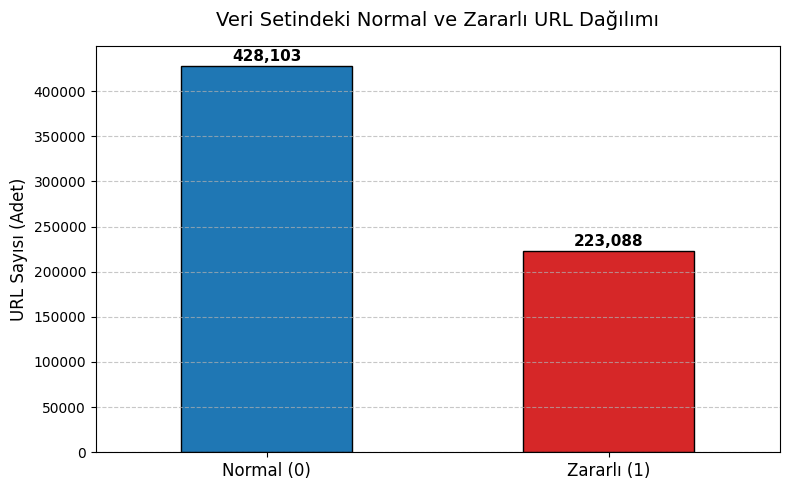

In [5]:
import matplotlib.pyplot as plt

# Sınıf dağılımını gösteren çubuk grafiği (Aşama 3 için eklendi)
plt.figure(figsize=(8, 5))
sinif_sayilari = df_real['label'].value_counts()
sinif_sayilari.index = ['Normal (0)', 'Zararlı (1)']

# Grafiği çizdir (Mavi ve Kırmızı renklerle)
grafik = sinif_sayilari.plot(kind='bar', color=['#1f77b4', '#d62728'], edgecolor='black')

plt.title('Veri Setindeki Normal ve Zararlı URL Dağılımı', fontsize=14, pad=15)
plt.ylabel('URL Sayısı (Adet)', fontsize=12)
plt.xticks(rotation=0, fontsize=12)

# Barların üstüne tam sayıları yazdır
for i, v in enumerate(sinif_sayilari):
    grafik.text(i, v + 5000, f"{v:,}", ha='center', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

NLP Modeli (Logistic Regression) eğitiliyor...
Lütfen bekle, bu işlem birkaç saniye sürebilir...

--- NLP MODEL KARNESİ ---
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     85778
           1       0.95      0.86      0.91     44461

    accuracy                           0.94    130239
   macro avg       0.94      0.92      0.93    130239
weighted avg       0.94      0.94      0.94    130239



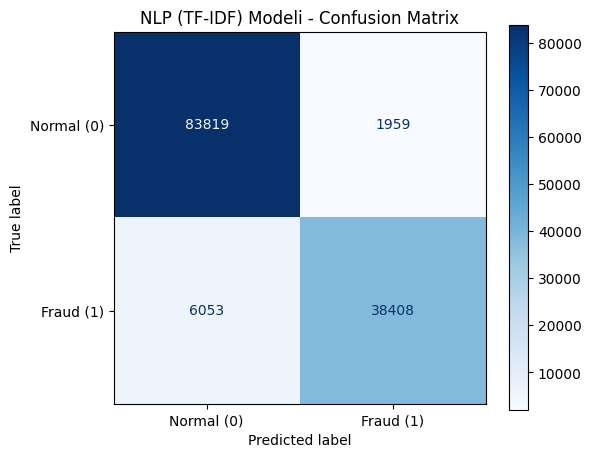

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Veriyi %80 Eğitim, %20 Test olarak bölüyoruz (Bu sefer X_tfidf matrisini kullanıyoruz)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, df_real['label'], test_size=0.2, random_state=42)

print("NLP Modeli (Logistic Regression) eğitiliyor...")
print("Lütfen bekle, bu işlem birkaç saniye sürebilir...")

# 2. Modeli tanımla ve eğit (max_iter=1000 büyük verilerde algoritmanın tam öğrenmesi için gereklidir)
nlp_model = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)
nlp_model.fit(X_train, y_train)

# 3. Test verisinde tahmin yap
y_pred_nlp = nlp_model.predict(X_test)

print("\n--- NLP MODEL KARNESİ ---")
print(classification_report(y_test, y_pred_nlp))

# 4. Confusion Matrix Görselleştirmesi
cm_nlp = confusion_matrix(y_test, y_pred_nlp)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nlp, display_labels=['Normal (0)', 'Fraud (1)'])
disp.plot(cmap='Blues', ax=ax)

plt.title('NLP (TF-IDF) Modeli - Confusion Matrix')
plt.grid(False)
plt.show()

In [4]:
# NLP MODELİ İÇİN CANLI TEST FONKSİYONU
def test_new_url_nlp(url):
    # 1. URL'yi modelin anlayacağı TF-IDF matrisine çevir
    # DİKKAT: Burada 'fit_transform' değil, SADECE 'transform' kullanıyoruz.
    # Çünkü modelin kelime dağarcığı eğitimde sabitlendi, dışarıdan yeni bir kelime ezberlememeli.
    url_tfidf = tfidf.transform([url])
    
    # 2. Modeli kullanarak tahmin ve olasılık hesaplama
    prediction = nlp_model.predict(url_tfidf)[0]
    probability = nlp_model.predict_proba(url_tfidf)[0][1] * 100 
    
    # 3. Sonucu ekrana yazdır
    print(f"İncelenen URL: {url}")
    if prediction == 1:
        print(f"🚨 RİSKLİ! (Zararlı Olma İhtimali: %{probability:.1f})")
    else:
        print(f"✅ GÜVENLİ. (Zararlı Olma İhtimali: %{probability:.1f})")
    print("-" * 40)

# 1. Veri setinin kendi içinden (Kaggle) seçtiğimiz NORMAL bir site
test_new_url_nlp("http://espn.go.com/nba/player/brandon-rush")

# 2. Küresel çapta herkesin bildiği, modelin aşina olduğu NORMAL bir site
test_new_url_nlp("https://www.apple.com")

# 3. Modelin öğrendiği kelimelerle (apple-id, login, verify) uydurduğumuz SİNSİ bir site
test_new_url_nlp("http://secure-login-apple-id-verify.com")

İncelenen URL: http://espn.go.com/nba/player/brandon-rush
✅ GÜVENLİ. (Zararlı Olma İhtimali: %2.1)
----------------------------------------
İncelenen URL: https://www.apple.com
🚨 RİSKLİ! (Zararlı Olma İhtimali: %100.0)
----------------------------------------
İncelenen URL: http://secure-login-apple-id-verify.com
🚨 RİSKLİ! (Zararlı Olma İhtimali: %100.0)
----------------------------------------


In [6]:
def canli_tahmin_uygulamasi():
    print("=" * 60)
    print(" 🛡️ SİBER GÜVENLİK: AKILLI URL KONTROL ARACINA HOŞ GELDİNİZ 🛡️ ")
    print("=" * 60)
    print("Çıkmak için 'q' veya 'quit' yazabilirsiniz.\n")
    
    while True:
        # Kullanıcıdan linki input() ile alıyoruz (Aşama 6 gereksinimi)
        kullanici_linki = input("👉 Şüphelendiğiniz linki buraya yapıştırın: ")
        
        # Çıkış kontrolü
        if kullanici_linki.lower() in ['q', 'quit', 'çıkış', 'cikis']:
            print("\nSistemden çıkılıyor. Güvenli günler dileriz!")
            break
            
        # Boş giriş kontrolü
        if kullanici_linki.strip() == "":
            print("Lütfen geçerli bir link girin!\n")
            continue
        
        # NLP modelimizi kullanarak tahmin yapıyoruz
        url_tfidf = tfidf.transform([kullanici_linki])
        prediction = nlp_model.predict(url_tfidf)[0]
        probability = nlp_model.predict_proba(url_tfidf)[0][1] * 100 
        
        # Kullanıcıya anlamlı ve formatlı bir çıktı veriyoruz
        print("\n⏳ Yapay Zeka Analiz Ediyor...")
        if prediction == 1:
            print(f"🚨 SONUÇ: RİSKLİ! (Zararlı olma ihtimali: %{probability:.1f})")
            print("⚠️ DİKKAT: Bu linke TIKLAMAYIN ve kişisel bilgilerinizi PAYLAŞMAYIN.")
        else:
            print(f"✅ SONUÇ: GÜVENLİ. (Zararlı olma ihtimali: %{probability:.1f})")
            print("👍 Site güvenli görünüyor, giriş yapabilirsiniz.")
        print("-" * 60 + "\n")

# Mini uygulamayı başlat
canli_tahmin_uygulamasi()

 🛡️ SİBER GÜVENLİK: AKILLI URL KONTROL ARACINA HOŞ GELDİNİZ 🛡️ 
Çıkmak için 'q' veya 'quit' yazabilirsiniz.


⏳ Yapay Zeka Analiz Ediyor...
🚨 SONUÇ: RİSKLİ! (Zararlı olma ihtimali: %100.0)
⚠️ DİKKAT: Bu linke TIKLAMAYIN ve kişisel bilgilerinizi PAYLAŞMAYIN.
------------------------------------------------------------


Sistemden çıkılıyor. Güvenli günler dileriz!


In [7]:
import joblib
joblib.dump(nlp_model, '../models/nlp_model.joblib')
joblib.dump(tfidf, '../models/tfidf_vectorizer.joblib')

['../models/tfidf_vectorizer.joblib']